# Stacked Auto-Encoder Implementation

### 0. pip

In [1]:
# you should run this only once - uncomment before first use
'''
%pip install pandas numpy matplotlib scikit-learn joblib tqdm
# if you want to use gpu, ensure you have cuda setup
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
'''

'\n%pip install pandas numpy matplotlib scikit-learn joblib tqdm\n# if you want to use gpu, ensure you have cuda setup\n%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126\n'

### 1. Imports

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import joblib
import os
from tqdm import tqdm

In [3]:
normal_data_file = 'checkpointing/normal_data_preprocessed.joblib'
attack_data_file = 'checkpointing/attack_data_preprocessed.joblib'
normal_csv_path = r'data\LMD-2023 [2.3M Elements - Normal]checked.csv'
eors_csv_path = r'data\LMD-2023 [2.3M Elements - EORS]checked.csv'
eoht_csv_path = r'data\LMD-2023 [2.3M Elements - EOHT]checked.csv'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 2. Data Loading & Preprocessing

In [4]:
# Check if checkpoint files exist
if os.path.exists(normal_data_file) and os.path.exists(attack_data_file):
    print("Checkpoint files found. Loading preprocessed data...")
    X_normal_preprocessed = joblib.load(normal_data_file)
    X_attack_preprocessed = joblib.load(attack_data_file)
    print("Data loaded successfully from checkpoints.")
else:
    print("Checkpoint files not found. Running full preprocessing pipeline...")
    # Load normal and attack datasets
    try:
        df_normal = pd.read_csv(normal_csv_path)
        df_attack_eors = pd.read_csv(eors_csv_path)
        df_attack_eoht = pd.read_csv(eoht_csv_path)
        df_attack = pd.concat([df_attack_eors, df_attack_eoht], ignore_index=True)
        print(f"Loaded {len(df_normal)} normal records and {len(df_attack)} attack records")
    except FileNotFoundError:
        print("Error: one of the dataset files not found. Please check the data folder.")

    # Feature selection as per Table 2 in the paper
    selected_features = [
        'Computer', 'DestinationPortName', 'EventID', 'EventRecordID',
        'Execution_ProcessID', 'Initiated', 'ProcessId', 'SourceIsIpv6',
        'SystemTime'
    ]

    # Process normal data
    df_normal['SystemTime'] = pd.to_datetime(df_normal['SystemTime'])
    df_normal['SystemTime_year'] = df_normal['SystemTime'].dt.year
    df_normal['SystemTime_month'] = df_normal['SystemTime'].dt.month
    df_normal['SystemTime_week'] = df_normal['SystemTime'].dt.isocalendar().week
    df_normal['SystemTime_day'] = df_normal['SystemTime'].dt.day
    df_normal['SystemTime_hour'] = df_normal['SystemTime'].dt.hour
    df_normal['SystemTime_minute'] = df_normal['SystemTime'].dt.minute
    df_normal['SystemTime_day_of_week'] = df_normal['SystemTime'].dt.dayofweek
    
    # Process attack data
    df_attack['SystemTime'] = pd.to_datetime(df_attack['SystemTime'])
    df_attack['SystemTime_year'] = df_attack['SystemTime'].dt.year
    df_attack['SystemTime_month'] = df_attack['SystemTime'].dt.month
    df_attack['SystemTime_week'] = df_attack['SystemTime'].dt.isocalendar().week
    df_attack['SystemTime_day'] = df_attack['SystemTime'].dt.day
    df_attack['SystemTime_hour'] = df_attack['SystemTime'].dt.hour
    df_attack['SystemTime_minute'] = df_attack['SystemTime'].dt.minute
    df_attack['SystemTime_day_of_week'] = df_attack['SystemTime'].dt.dayofweek
    
    time_features = ['SystemTime_year', 'SystemTime_month', 'SystemTime_week', 'SystemTime_day', 'SystemTime_hour', 'SystemTime_minute', 'SystemTime_day_of_week']
    final_features = selected_features[:-1] + time_features
    
    # Select features for both datasets
    X_normal = df_normal[final_features]
    X_attack = df_attack[final_features]

    # Define feature types
    categorical_features = ['Computer', 'DestinationPortName', 'EventID', 'Initiated', 'SourceIsIpv6', 'SystemTime_year', 'SystemTime_month', 'SystemTime_week', 'SystemTime_day_of_week']
    numerical_features = ['EventRecordID', 'Execution_ProcessID', 'ProcessId', 'SystemTime_day', 'SystemTime_hour', 'SystemTime_minute']
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', MinMaxScaler(), numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ])

    # Fit preprocessor on normal data and transform both datasets
    X_normal_preprocessed = preprocessor.fit_transform(X_normal)
    X_attack_preprocessed = preprocessor.transform(X_attack)
    
    # Save the processed data
    print("Saving processed data to disk...")
    joblib.dump(X_normal_preprocessed, normal_data_file)
    joblib.dump(X_attack_preprocessed, attack_data_file)
    print("Checkpoint files saved successfully.")

# Split normal data into train and test sets
X_train, X_test = train_test_split(
    X_normal_preprocessed, 
    test_size=0.2, 
    random_state=42, 
    shuffle=True
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Attack data size: {X_attack_preprocessed.shape[0]}")


Checkpoint files found. Loading preprocessed data...
Data loaded successfully from checkpoints.
Training set size: 1306322
Test set size: 326581
Attack data size: 511105
Training set size: 1306322
Test set size: 326581
Attack data size: 511105


### 3. Stacked Auto-Encoder Architecture

In [5]:
class StackedAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(StackedAutoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.BatchNorm1d(50),
            #nn.Dropout(0.15),
            nn.ReLU(inplace=True),
            nn.Linear(50, 30),
            nn.BatchNorm1d(30),
            #nn.Dropout(0.15),
            nn.ReLU(inplace=True),
            nn.Linear(30, 20),
            nn.BatchNorm1d(20),
            #nn.Dropout(0.15),
            nn.ReLU(inplace=True),
            nn.Linear(20, 10),
            nn.BatchNorm1d(10),
            #nn.Dropout(0.15),
            nn.ReLU(inplace=True),
            nn.Linear(10, 5), # Latent space
            nn.ReLU(inplace=True)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(5, 10),
            nn.BatchNorm1d(10),
            #nn.Dropout(0.15),
            nn.ReLU(inplace=True),
            nn.Linear(10, 20),
            nn.BatchNorm1d(20),
            #nn.Dropout(0.15),
            nn.ReLU(inplace=True),
            nn.Linear(20, 30),
            nn.BatchNorm1d(30),
            #nn.Dropout(0.15),
            nn.ReLU(inplace=True),
            nn.Linear(30, 50),
            nn.BatchNorm1d(50),
            #nn.Dropout(0.15),
            nn.ReLU(inplace=True),
            nn.Linear(50, input_dim),
            nn.Sigmoid() # To output values between 0 and 1
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Get input dimension from preprocessed data
input_dim = X_train.shape[1]
model = StackedAutoencoder(input_dim)
print(model)

StackedAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=71, out_features=50, bias=True)
    (1): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=50, out_features=30, bias=True)
    (4): BatchNorm1d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=30, out_features=20, bias=True)
    (7): BatchNorm1d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Linear(in_features=20, out_features=10, bias=True)
    (10): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Linear(in_features=10, out_features=5, bias=True)
    (13): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=5, out_features=10, bias=True)
    (1): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track

### 4. Training

In [6]:
# Use only training data for training the autoencoder
X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32).to(device)
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)

# Move model to device
model = model.to(device)

# Hyperparameters
batch_size = 50
epochs = 40
learning_rate = 1e-3
weight_decay = 1e-5

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Training loop with tqdm for epochs only
for epoch in tqdm(range(epochs), desc="Training Epochs"):
    running_loss = 0.0
    
    for batch_idx, data in enumerate(train_loader):
        inputs, _ = data
        inputs = inputs.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, inputs)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        # Print progress every 1000 batches
        if (batch_idx + 1) % 1000 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}")
    
    avg_loss = running_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{epochs}], Average Loss: {avg_loss:.4f}')

# save the model
#torch.save(model.state_dict(), "checkpointing/final_model.pth")

Training Epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch [1/40], Batch [1000/26127], Loss: 0.0950
Epoch [1/40], Batch [2000/26127], Loss: 0.0724
Epoch [1/40], Batch [2000/26127], Loss: 0.0724
Epoch [1/40], Batch [3000/26127], Loss: 0.0614
Epoch [1/40], Batch [3000/26127], Loss: 0.0614
Epoch [1/40], Batch [4000/26127], Loss: 0.0574
Epoch [1/40], Batch [4000/26127], Loss: 0.0574
Epoch [1/40], Batch [5000/26127], Loss: 0.0498
Epoch [1/40], Batch [5000/26127], Loss: 0.0498
Epoch [1/40], Batch [6000/26127], Loss: 0.0489
Epoch [1/40], Batch [6000/26127], Loss: 0.0489
Epoch [1/40], Batch [7000/26127], Loss: 0.0445
Epoch [1/40], Batch [7000/26127], Loss: 0.0445
Epoch [1/40], Batch [8000/26127], Loss: 0.0509
Epoch [1/40], Batch [8000/26127], Loss: 0.0509
Epoch [1/40], Batch [9000/26127], Loss: 0.0538
Epoch [1/40], Batch [9000/26127], Loss: 0.0538
Epoch [1/40], Batch [10000/26127], Loss: 0.0417
Epoch [1/40], Batch [10000/26127], Loss: 0.0417
Epoch [1/40], Batch [11000/26127], Loss: 0.0353
Epoch [1/40], Batch [11000/26127], Loss: 0.0353
Epoch [1/

Training Epochs:   2%|▎         | 1/40 [01:27<57:02, 87.75s/it]

Epoch [1/40], Average Loss: 0.0477
Epoch [2/40], Batch [1000/26127], Loss: 0.0337
Epoch [2/40], Batch [1000/26127], Loss: 0.0337
Epoch [2/40], Batch [2000/26127], Loss: 0.0324
Epoch [2/40], Batch [2000/26127], Loss: 0.0324
Epoch [2/40], Batch [3000/26127], Loss: 0.0340
Epoch [2/40], Batch [3000/26127], Loss: 0.0340
Epoch [2/40], Batch [4000/26127], Loss: 0.0322
Epoch [2/40], Batch [4000/26127], Loss: 0.0322
Epoch [2/40], Batch [5000/26127], Loss: 0.0333
Epoch [2/40], Batch [5000/26127], Loss: 0.0333
Epoch [2/40], Batch [6000/26127], Loss: 0.0315
Epoch [2/40], Batch [6000/26127], Loss: 0.0315
Epoch [2/40], Batch [7000/26127], Loss: 0.0311
Epoch [2/40], Batch [7000/26127], Loss: 0.0311
Epoch [2/40], Batch [8000/26127], Loss: 0.0317
Epoch [2/40], Batch [8000/26127], Loss: 0.0317
Epoch [2/40], Batch [9000/26127], Loss: 0.0349
Epoch [2/40], Batch [9000/26127], Loss: 0.0349
Epoch [2/40], Batch [10000/26127], Loss: 0.0341
Epoch [2/40], Batch [10000/26127], Loss: 0.0341
Epoch [2/40], Batch [11

Training Epochs:   5%|▌         | 2/40 [03:49<1:15:49, 119.72s/it]

...

Epoch [17/40], Average Loss: 0.0277
Epoch [18/40], Batch [1000/26127], Loss: 0.0271
Epoch [18/40], Batch [1000/26127], Loss: 0.0271
Epoch [18/40], Batch [2000/26127], Loss: 0.0336
Epoch [18/40], Batch [2000/26127], Loss: 0.0336
Epoch [18/40], Batch [3000/26127], Loss: 0.0259
Epoch [18/40], Batch [3000/26127], Loss: 0.0259
Epoch [18/40], Batch [4000/26127], Loss: 0.0269
Epoch [18/40], Batch [4000/26127], Loss: 0.0269
Epoch [18/40], Batch [5000/26127], Loss: 0.0281
Epoch [18/40], Batch [5000/26127], Loss: 0.0281
Epoch [18/40], Batch [6000/26127], Loss: 0.0269
Epoch [18/40], Batch [6000/26127], Loss: 0.0269
Epoch [18/40], Batch [7000/26127], Loss: 0.0276
Epoch [18/40], Batch [7000/26127], Loss: 0.0276
Epoch [18/40], Batch [8000/26127], Loss: 0.0277
Epoch [18/40], Batch [8000/26127], Loss: 0.0277
Epoch [18/40], Batch [9000/26127], Loss: 0.0271
Epoch [18/40], Batch [9000/26127], Loss: 0.0271
Epoch [18/40], Batch [10000/26127], Loss: 0.0266
Epoch [18/40], Batch [10000/26127], Loss: 0.0266
Ep

Training Epochs:  45%|████▌     | 18/40 [28:26<33:42, 91.95s/it]

Epoch [18/40], Average Loss: 0.0276
Epoch [19/40], Batch [1000/26127], Loss: 0.0282
Epoch [19/40], Batch [1000/26127], Loss: 0.0282
Epoch [19/40], Batch [2000/26127], Loss: 0.0265
Epoch [19/40], Batch [2000/26127], Loss: 0.0265
Epoch [19/40], Batch [3000/26127], Loss: 0.0270
Epoch [19/40], Batch [3000/26127], Loss: 0.0270
Epoch [19/40], Batch [4000/26127], Loss: 0.0266
Epoch [19/40], Batch [4000/26127], Loss: 0.0266
Epoch [19/40], Batch [5000/26127], Loss: 0.0279
Epoch [19/40], Batch [5000/26127], Loss: 0.0279
Epoch [19/40], Batch [6000/26127], Loss: 0.0273
Epoch [19/40], Batch [6000/26127], Loss: 0.0273
Epoch [19/40], Batch [7000/26127], Loss: 0.0318
Epoch [19/40], Batch [7000/26127], Loss: 0.0318
Epoch [19/40], Batch [8000/26127], Loss: 0.0261
Epoch [19/40], Batch [8000/26127], Loss: 0.0261


Training Epochs:  45%|████▌     | 18/40 [28:57<35:23, 96.51s/it]



KeyboardInterrupt: 

### 5. Evaluation

In [14]:
#load the model
#model.load_state_dict(torch.load("checkpointing/final_model.pth"))
torch.save(model.state_dict(), "checkpointing/final_model.pth")

# Convert test and attack data to tensors
X_test_tensor = torch.tensor(X_test.toarray(), dtype=torch.float32).to(device)
X_attack_tensor = torch.tensor(X_attack_preprocessed.toarray(), dtype=torch.float32).to(device)

# Calculate reconstruction errors for test data (unseen normal data)
model.eval() # Set the model to evaluation mode
with torch.no_grad():
    reconstructions_test = model(X_test_tensor)
    mse_test = nn.MSELoss(reduction='none')(reconstructions_test, X_test_tensor)
    test_errors = torch.mean(mse_test, dim=1)

# Calculate reconstruction errors for attack data
with torch.no_grad():
    reconstructions_attack = model(X_attack_tensor)
    mse_attack = nn.MSELoss(reduction='none')(reconstructions_attack, X_attack_tensor)
    attack_errors = torch.mean(mse_attack, dim=1)

print(f"\nAverage reconstruction error for test normal data: {torch.mean(test_errors):.4f}")
print(f"Average reconstruction error for attack data: {torch.mean(attack_errors):.4f}")

# Determine threshold based on test data (99th percentile)
threshold = np.percentile(test_errors.cpu().numpy(), 99.9) # Move to CPU for numpy operations
print(f"Threshold for anomaly detection: {threshold:.4f}")

# Evaluate on attack data
predictions_attack = (attack_errors.cpu().numpy() > threshold)
accuracy_attack = np.sum(predictions_attack) / len(attack_errors)
print(f"Anomalies correctly detected in attack data: {np.sum(predictions_attack)} / {len(attack_errors)} ({accuracy_attack:.2%})")

# Evaluate on test normal data
predictions_test = (test_errors.cpu().numpy() > threshold)
false_positive_rate = np.sum(predictions_test) / len(test_errors) 
print(f"False positives in test normal data: {np.sum(predictions_test)} / {len(test_errors)} ({false_positive_rate:.2%})")


Average reconstruction error for test normal data: 0.0004
Average reconstruction error for attack data: 0.0714
Threshold for anomaly detection: 0.0177
Anomalies correctly detected in attack data: 491106 / 511105 (96.09%)
False positives in test normal data: 327 / 326581 (0.10%)


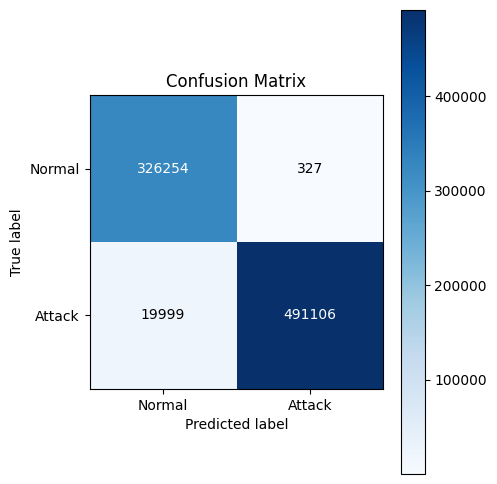

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# true labels: 0 for normal, 1 for attack
y_true = np.concatenate([
    np.zeros(len(predictions_test), dtype=int),
    np.ones(len(predictions_attack), dtype=int)
])
# predicted labels: cast booleans to int
y_pred = np.concatenate([
    predictions_test.astype(int),
    predictions_attack.astype(int)
])

# compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# plot
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(cm, cmap="Blues", interpolation="nearest")
ax.figure.colorbar(im, ax=ax)
classes = ['Normal', 'Attack']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Confusion Matrix')

# annotate counts
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()